<a href="https://colab.research.google.com/github/Nawshin-25/Geo_Analysis/blob/Analysis/Climate_Temp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install cartopy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 98.7 MB/s eta 0:00:00


In [ ]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import linregress
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [ ]:
file_name = '/content/drive/MyDrive/CC_CHA/SST.nc'
ds = xr.open_dataset(file_name)
print (ds)
sst = ds['sst']
time = ds['valid_time']

<xarray.Dataset> Size: 20MB
Dimensions:     (valid_time: 28492, latitude: 13, longitude: 13)
Coordinates:
    number      int64 8B ...
  * valid_time  (valid_time) datetime64[ns] 228kB 1980-01-01 ... 2020-12-31T1...
  * latitude    (latitude) float64 104B 23.0 22.75 22.5 ... 20.5 20.25 20.0
  * longitude   (longitude) float64 104B 90.0 90.25 90.5 ... 92.5 92.75 93.0
    expver      (valid_time) <U4 456kB ...
Data variables:
    sst         (valid_time, latitude, longitude) float32 19MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-03-24T18:41 GRIB to CDM+CF via cfgrib-0.9.1...


In [ ]:
time = pd.to_datetime(time.values)
climatology = sst.groupby('valid_time.month').mean('valid_time')

sst_anomaly = sst.groupby('valid_time.month') - climatology
sst_anomaly_annual = sst_anomaly.resample(valid_time='Y').mean()
years = sst_anomaly_annual.valid_time.dt.year.values
sst_anomaly_values = sst_anomaly_annual.mean(dim=['latitude', 'longitude']).values
valid_indices = ~np.isnan(sst_anomaly_values)  # Get indices where values are valid
years_clean = years[valid_indices]
sst_anomaly_clean = sst_anomaly_values[valid_indices]
slope, intercept, r_value, p_value, std_err = linregress(years_clean, sst_anomaly_clean)
trendline = slope * years_clean + intercept  # Compute trendline values

/usr/local/lib/python3.11/dist-packages/xarray/groupers.py:487: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  self.index_grouper = pd.Grouper(


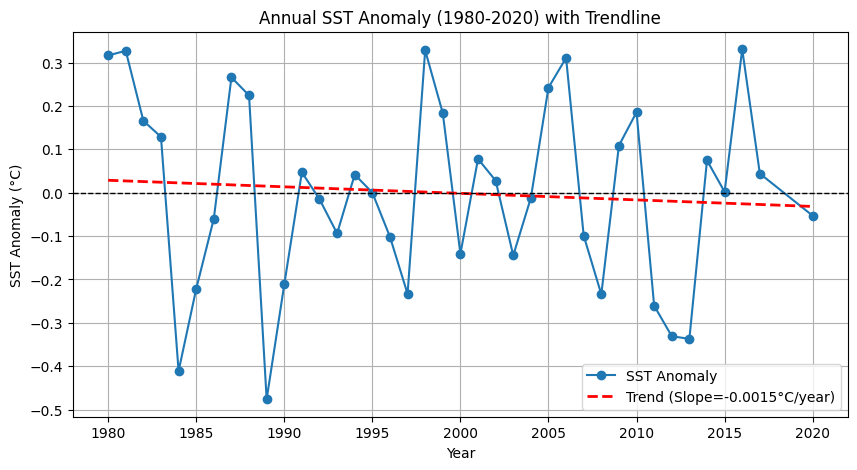

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(years_clean, sst_anomaly_clean, marker='o', linestyle='-', label='SST Anomaly')
plt.plot(years_clean, trendline, color='red', linestyle='--', linewidth=2, label=f'Trend (Slope={slope:.4f}°C/year)')
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.xlabel('Year')
plt.ylabel('SST Anomaly (°C)')
plt.title('Annual SST Anomaly (1980-2020) with Trendline')
plt.legend()
plt.grid()
plt.show()

In [ ]:
climatology = sst.groupby('valid_time.month').mean('valid_time')
sst_anomaly = sst.groupby('valid_time.month') - climatology
sst_anomaly_annual = sst_anomaly.resample(valid_time='Y').mean()

years = sst_anomaly_annual.valid_time.dt.year.values
sst_anomaly_values = sst_anomaly_annual.mean(dim=['latitude', 'longitude']).values

valid_indices = ~np.isnan(sst_anomaly_values)  # Get indices where values are valid
years_clean = years[valid_indices]
sst_anomaly_clean = sst_anomaly_values[valid_indices]

# Define time periods
time_periods = [
    (1981, 1990),
    (1991, 2000),
    (2001, 2010),
    (2011, 2020)
]

/usr/local/lib/python3.11/dist-packages/xarray/groupers.py:487: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  self.index_grouper = pd.Grouper(


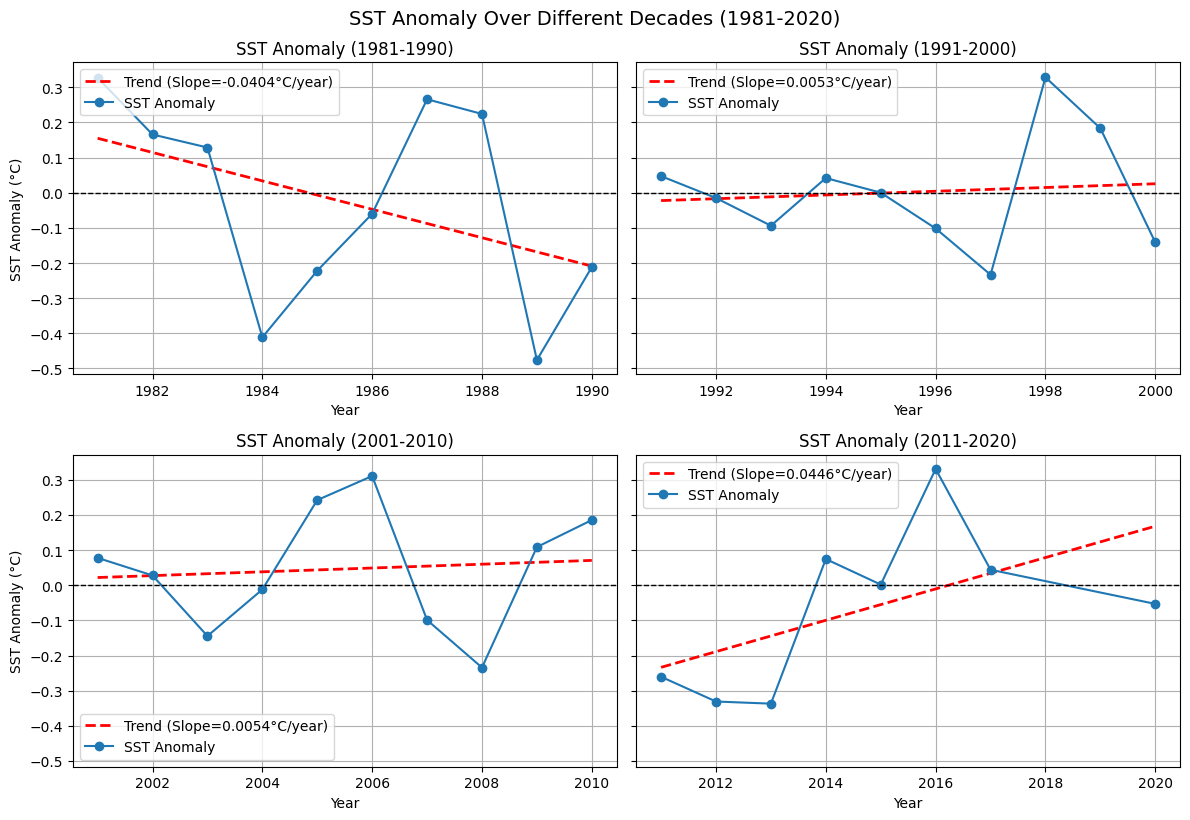

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey=True)

for i, (start, end) in enumerate(time_periods):
    ax = axes[i // 2, i % 2]  # Position in subplot grid

    # Filter data for the given decade
    mask = (years_clean >= start) & (years_clean <= end)
    years_subset = years_clean[mask]
    sst_anomaly_subset = sst_anomaly_clean[mask]

    # Perform linear regression for trendline
    if len(years_subset) > 1:  # Ensure there are enough points for regression
        slope, intercept, r_value, p_value, std_err = linregress(years_subset, sst_anomaly_subset)
        trendline = slope * years_subset + intercept
        ax.plot(years_subset, trendline, color='red', linestyle='--', linewidth=2, label=f'Trend (Slope={slope:.4f}°C/year)')

    # Plot anomaly
    ax.plot(years_subset, sst_anomaly_subset, marker='o', linestyle='-', label='SST Anomaly')

    # Formatting
    ax.set_title(f'SST Anomaly ({start}-{end})')
    ax.axhline(0, color='black', linestyle='--', linewidth=1)
    ax.set_xlabel('Year')
    if i % 2 == 0:
        ax.set_ylabel('SST Anomaly (°C)')
    ax.legend()
    ax.grid()

# Adjust layout
plt.tight_layout()
plt.suptitle('SST Anomaly Over Different Decades (1981-2020)', fontsize=14, y=1.02)
plt.show()

In [ ]:
seasons = {
    "Premonsoon (Feb-Apr)": [2, 3, 4],
    "Monsoon (May-Jul)": [5, 6, 7],
    "Postmonsoon (Aug-Oct)": [8, 9, 10],
    "Winter (Nov-Jan)": [11, 12, 1]
}

In [ ]:
# Compute monthly climatology (long-term mean for each month)
climatology = sst.groupby('valid_time.month').mean('valid_time')

# Compute SST anomaly
sst_anomaly = sst.groupby('valid_time.month') - climatology

# Define time periods (each period covers 10 years)
time_periods = [
    (1981, 1990),
    (1991, 2000),
    (2001, 2010),
    (2011, 2020)
]

<ipython-input-32-5dd2477dc39d>:36: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.85, 1])  # Prevent overlap


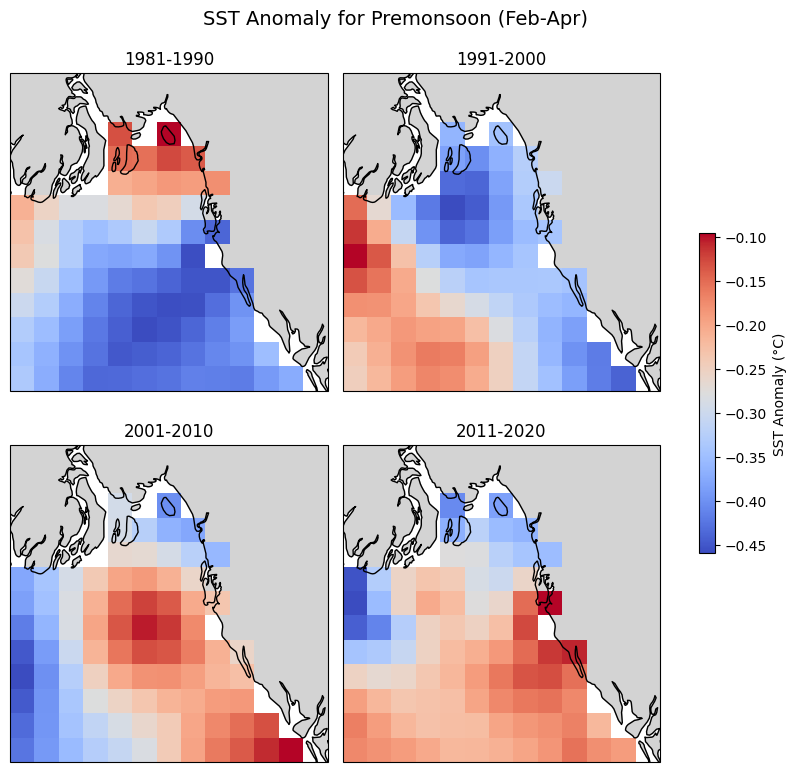

<ipython-input-32-5dd2477dc39d>:36: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.85, 1])  # Prevent overlap


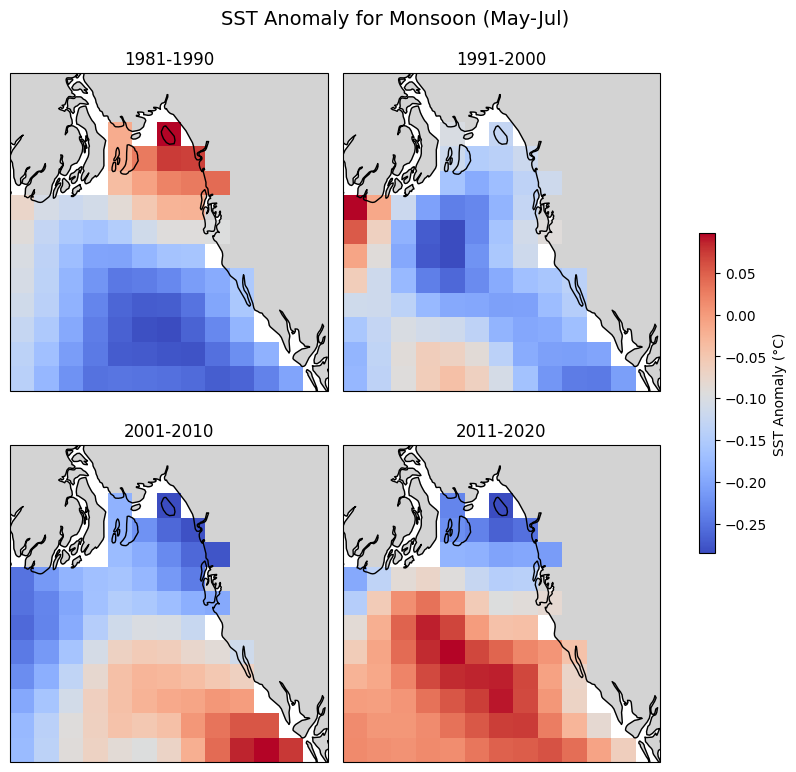

<ipython-input-32-5dd2477dc39d>:36: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.85, 1])  # Prevent overlap


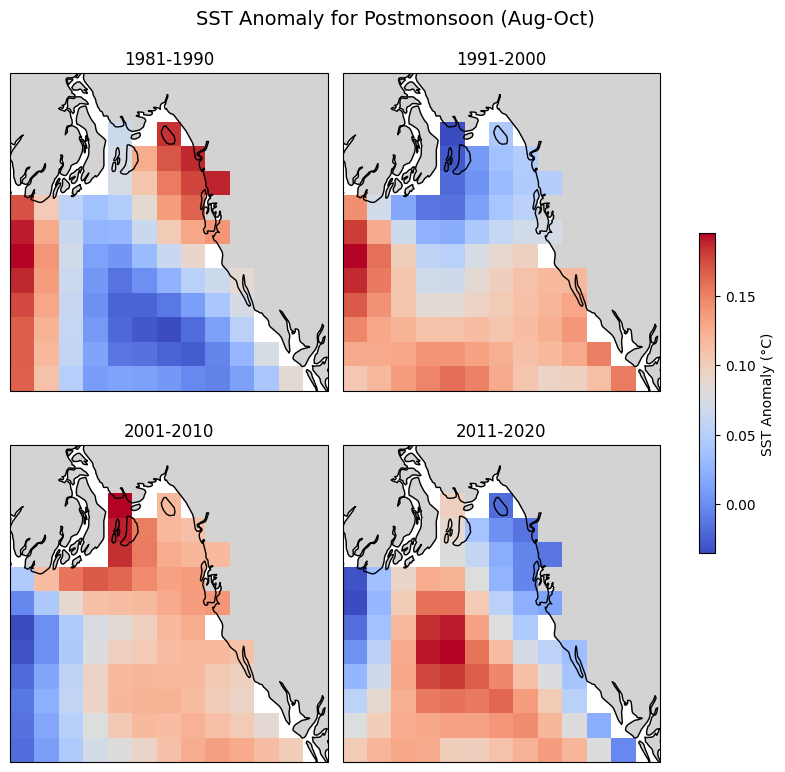

<ipython-input-32-5dd2477dc39d>:36: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.85, 1])  # Prevent overlap


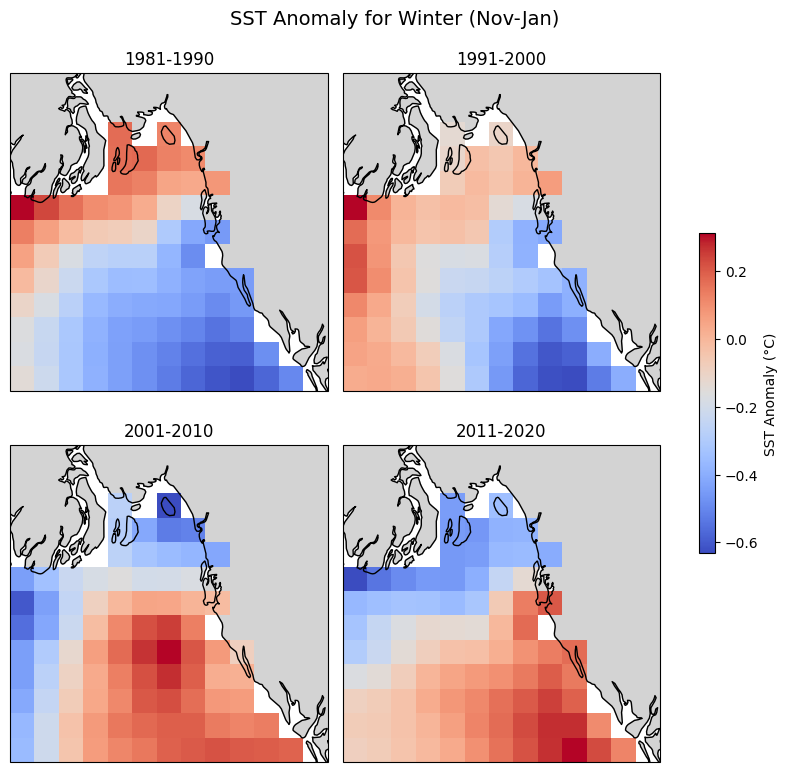

In [ ]:
for season_name, months in seasons.items():
    fig, axes = plt.subplots(2, 2, figsize=(8, 8), subplot_kw={'projection': ccrs.PlateCarree()})
    fig.subplots_adjust(right=0.85)  # Adjust layout to prevent overlap

    # Create an axis for the colorbar
    cbar_ax = fig.add_axes([0.88, 0.3, 0.02, 0.4])  # [left, bottom, width, height]

    for i, (start, end) in enumerate(time_periods):
        ax = axes[i // 2, i % 2]  # Position in subplot grid

        # Create a mask to filter data for the current season and decade.
        if 1 in months:  # Special handling for Winter (Nov, Dec, Jan)
            mask = (((time.dt.year == start) & (time.dt.month.isin([11, 12]))) |
                    ((time.dt.year == start+1) & (time.dt.month == 1)))
            for yr in range(start+1, end):
                mask = mask | (((time.dt.year == yr) & (time.dt.month.isin([11, 12]))) |
                               ((time.dt.year == yr+1) & (time.dt.month == 1)))
            sst_seasonal_anomaly = sst_anomaly.sel(valid_time=mask).mean(dim='valid_time')
        else:
            mask = (time.dt.year >= start) & (time.dt.year <= end) & (time.dt.month.isin(months))
            sst_seasonal_anomaly = sst_anomaly.sel(valid_time=mask).mean(dim='valid_time')

        # Plot the spatial anomaly
        im = ax.pcolormesh(ds.longitude, ds.latitude, sst_seasonal_anomaly, cmap='coolwarm', transform=ccrs.PlateCarree())
        ax.add_feature(cfeature.LAND, color='lightgray')
        ax.add_feature(cfeature.COASTLINE, linewidth=1)
        ax.set_title(f'{start}-{end}')
        ax.set_xlabel('Longitude')
        ax.set_ylabel('Latitude')

    # Add a common colorbar outside the plot
    cbar = fig.colorbar(im, cax=cbar_ax)
    cbar.set_label('SST Anomaly (°C)')

    plt.suptitle(f'SST Anomaly for {season_name}', fontsize=14, y=0.98)
    plt.tight_layout(rect=[0, 0, 0.85, 1])  # Prevent overlap
    plt.show()